In [1]:
import os.path
import traceback
import zipfile

import pyreadstat
import seaborn as sns
from pandas import DataFrame
import matplotlib.pyplot as plt

from util.download_util import download_files
from util.dta_file_utils import find_dta_file

In [2]:
# High-contrast, bright colors for dark backgrounds
dark_palette = sns.color_palette("bright")  # 8 vivid colors
# Or use more colors:
# dark_palette = sns.color_palette("tab20", 20)

sns.set_palette(dark_palette)   # sets palette globally
sns.set_style("darkgrid")       # dark background grid
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.facecolor"] = "#2b2b2b"  # match IntelliJ dark editor bg
plt.rcParams["figure.facecolor"] = "#2b2b2b"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["xtick.color"] = "white"
plt.rcParams["ytick.color"] = "white"
plt.rcParams["text.color"] = "white"

In [3]:
STATA_BASE_URL = "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Dataset_Documentation/NHAMCS/stata/"
DOC_BASE_URL = "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Dataset_Documentation/NHAMCS/"
DATA_BASE_PATH = "data"
DOC_BASE_PATH = "doc"
os.makedirs(DATA_BASE_PATH, exist_ok=True)
os.makedirs(DOC_BASE_PATH, exist_ok=True)

In [4]:
urls = []
pdf_urls = []
years = ["2022"]
stata_zip_file_names = []
pdf_file_names = []
for year in years:
    file_name = f"ED{year}-stata.zip"
    yy = year[-2:]
    pdf_file_name = f"doc{yy}-ed-508.pdf"
    pdf_url = DOC_BASE_URL + pdf_file_name
    pdf_urls.append(pdf_url)
    pdf_file_names.append(os.path.join(DOC_BASE_PATH, pdf_file_name))
    url = STATA_BASE_URL + file_name
    urls.append(url)
    stata_zip_file_names.append(os.path.join(DATA_BASE_PATH, file_name))

In [5]:
await download_files(urls, stata_zip_file_names)
await download_files(pdf_urls, pdf_file_names)

data\ED2022-stata.zip: 100%|██████████| 2.31M/2.31M [00:01<00:00, 2.03MB/s]
doc\doc22-ed-508.pdf: 100%|██████████| 2.65M/2.65M [00:01<00:00, 2.33MB/s]


In [6]:
df: DataFrame = None
meta = None
for file_name in stata_zip_file_names:
    with zipfile.ZipFile(file_name, "r") as z:
        for stata_file in find_dta_file(z.namelist()):
            print(stata_file)
            with z.open(stata_file) as f:
                try:
                    df, meta = pyreadstat.read_dta(f)
                except Exception as e:
                    print("Could not read stata file:", stata_file)
                    traceback.print_exc()



ed2022-stata.dta


In [7]:
for col in df.columns:
    print(col)

VMONTH
VDAYR
ARRTIME
WAITTIME
LOV
AGE
AGER
AGEDAYS
RESIDNCE
SEX
ETHUN
ETHIM
RACEUN
RACER
RACERETH
ARREMS
AMBTRANSFER
NOPAY
PAYPRIV
PAYMCARE
PAYMCAID
PAYWKCMP
PAYSELF
PAYNOCHG
PAYOTH
PAYDK
PAYTYPER
TEMPF
PULSE
RESPR
BPSYS
BPDIAS
POPCT
IMMEDR
PAINSCALE
SEEN72
RFV1
RFV2
RFV3
RFV4
RFV5
RFV13D
RFV23D
RFV33D
RFV43D
RFV53D
EPISODE
INJURY
INJPOISAD
INJURY72
INTENT15
INJURY_ENC
CAUSE1
CAUSE2
CAUSE3
DIAG1
DIAG2
DIAG3
DIAG4
DIAG5
PRDIAG1
PRDIAG2
PRDIAG3
PRDIAG4
PRDIAG5
ETOHAB
ALZHD
ASTHMA
CANCER
CEBVD
CKD
COPD
CHF
CAD
DEPRN
DIABTYP1
DIABTYP2
DIABTYP0
ESRD
HPE
EDHIV
HYPLIPID
HTN
OBESITY
OSA
OSTPRSIS
SUBSTAB
NOCHRON
TOTCHRON
DIAGSCRN
ABG
BAC
BMP
BNP
BUNCREAT
CARDENZ
CBC
CMP
BLOODCX
TRTCX
URINECX
WOUNDCX
OTHCX
DDIMER
ELECTROL
GLUCOSE
LACTATE
LFT
PTTINR
OTHERBLD
CARDMON
EKG
HIVTEST
FLUTEST
PREGTEST
TOXSCREN
URINE
OTHRTEST
ANYIMAGE
XRAY
CATSCAN
CTCONTRAST
CTAB
CTCHEST
CTHEAD
CTOTHER
CTUNK
MRI
MRICONTRAST
ULTRASND
OTHIMAGE
COVIDTEST
COVIDANTIBODY
TOTDIAG
PROC
BPAP
BLADCATH
CASTSPLINT
CENTLINE
CPR
ENDOI

In [8]:
print(len(df.columns))

913


## Initial Assessment of the 2022 NHAMCS ED Variables
1. **Description of Data** - Each record represents one sampled ED visit
2. **Number of Columns** - 913 (High dimensional)

## Next Steps
We need to first understand what variables are needed before triage. Additionally after predicting triage acuity. After predicting the triage acuity we can predict the safest wait time possible.

## Descriptive Variables
1. SEX - Gender of the patient
   1. 1 = Female
   2. 2 = Male
## Variables needed during Triage
1. IMMEDR (TARGET) - Immediacy with which patient should be seen.
   1. Key codes:
      1. 1 = Immediate
      2. 2 = Emergent
      3. 3 = Urgent
      4. 4 = Semi-urgent
      5. 0 = "No triage" but Emergency Service Area (ESA) of the hospital conducts nursing triage
      6. 7 = ESA does not conduct nursing triage
      7. -8 = Unknown; -9 = Blank


In [9]:
df["IMMEDR"].value_counts()

IMMEDR
 3    5340
-8    3788
 4    2826
 2    1595
 7    1079
 0     587
-9     364
 5     307
 1     139
Name: count, dtype: int64

In [10]:
df["IMMEDR"].describe()

count    16025.000000
mean         0.384462
std          5.179554
min         -9.000000
25%         -8.000000
50%          3.000000
75%          4.000000
max          7.000000
Name: IMMEDR, dtype: float64

<Axes: xlabel='IMMEDR', ylabel='count'>

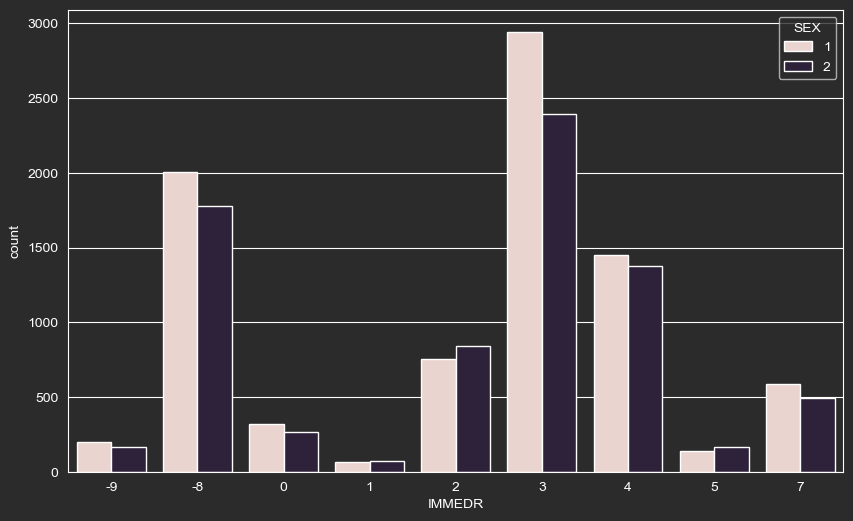

In [11]:
sns.countplot(df, x="IMMEDR", hue="SEX")

In [12]:
df.groupby("SEX")["IMMEDR"].describe()

,count,mean,std,min,25%,50%,75%,max
SEX,,,,,,,,
1,8465.0,0.377673,5.191894,-9.0,-8.0,3.0,4.0,7.0
2,7560.0,0.392063,5.166034,-9.0,-8.0,3.0,4.0,7.0


<Axes: xlabel='VMONTH', ylabel='IMMEDR'>

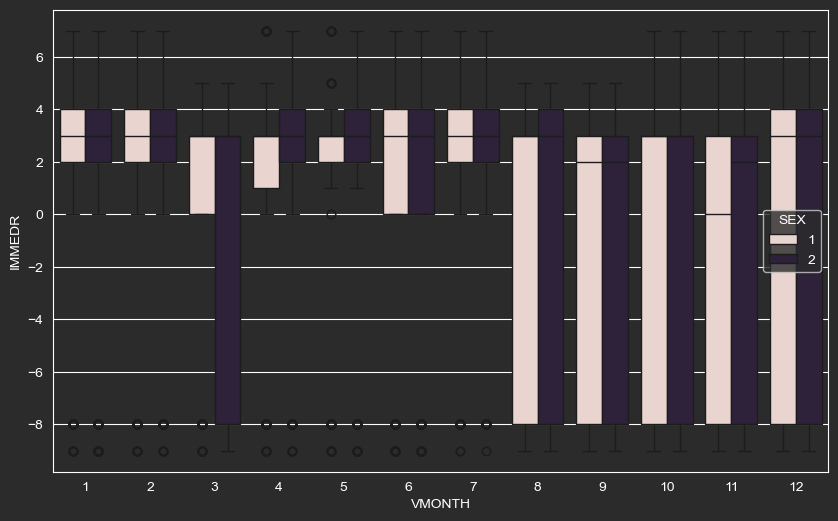

In [13]:
sns.boxplot(x="VMONTH", y="IMMEDR", data=df,hue="SEX")

In [14]:
df.groupby("VMONTH")["IMMEDR"].describe()

,count,mean,std,min,25%,50%,75%,max
VMONTH,,,,,,,,
1,1468.0,2.025886,4.346842,-9.0,2.0,3.0,4.0,7.0
2,1619.0,1.711550,4.266631,-9.0,2.0,3.0,4.0,7.0
3,1388.0,-0.125360,5.069537,-9.0,-8.0,3.0,3.0,5.0
4,1367.0,0.527432,4.913954,-9.0,1.0,3.0,3.0,7.0
5,1135.0,1.614978,3.956860,-9.0,2.0,3.0,4.0,7.0
6,1408.0,0.949574,5.097446,-9.0,0.0,3.0,4.0,7.0
7,1448.0,1.345304,4.977444,-9.0,2.0,3.0,4.0,7.0
8,1293.0,-1.119876,5.608652,-9.0,-8.0,3.0,3.0,5.0
9,763.0,-1.216252,5.420545,-9.0,-8.0,2.0,3.0,5.0


<Axes: xlabel='VMONTH', ylabel='IMMEDR'>

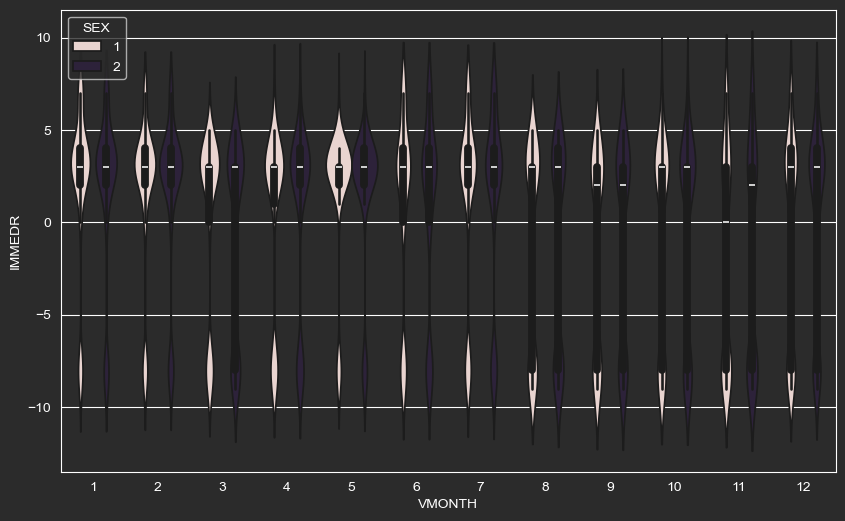

In [15]:
sns.violinplot(x="VMONTH", y="IMMEDR", data=df,hue="SEX")

## What is the age distribution of ED visits?

In [16]:
df["AGE"].value_counts()

AGE
0     428
1     333
2     283
31    258
30    254
     ... 
89     53
91     45
90     43
92     27
93     26
Name: count, Length: 95, dtype: int64

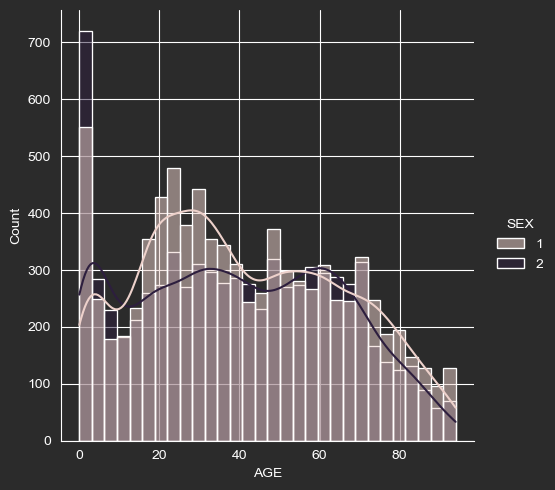

In [17]:
sns.displot(data=df,x="AGE",hue="SEX",kde=True)

In [18]:
df["AGE"].describe()

count    16025.000000
mean        40.266396
std         24.968400
min          0.000000
25%         20.000000
50%         38.000000
75%         60.000000
max         94.000000
Name: AGE, dtype: float64

In [19]:
df["AGER"].value_counts()

AGER
3    4170
4    3703
1    2849
2    2084
6    1638
5    1581
Name: count, dtype: int64

<Axes: xlabel='AGER', ylabel='count'>

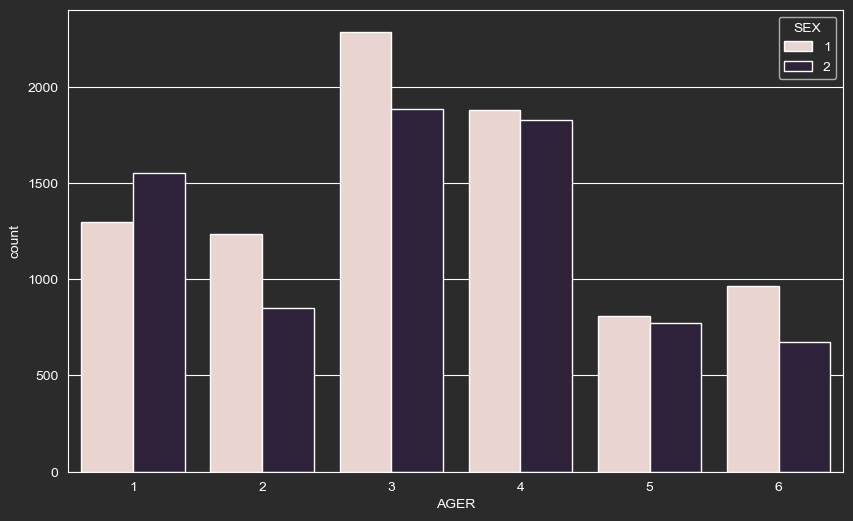

In [20]:
sns.countplot(data=df,x="AGER",hue="SEX")

## Which age groups account for the largest share of ED visits?

| AGER Code | Age Group   |
| --------- | ----------- |
| 1         | 0–14 years  |
| 2         | 15–24 years |
| 3         | 25–44 years |
| 4         | 45–64 years |
| 5         | 65–74 years |
| 6         | 75+ years   |


In [21]:
df["AGER"].describe()

count    16025.000000
mean         3.249423
std          1.524718
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          6.000000
Name: AGER, dtype: float64

In [22]:
df.groupby("SEX")["AGER"].describe()

,count,mean,std,min,25%,50%,75%,max
SEX,,,,,,,,
1,8465.0,3.302304,1.514868,1.0,2.0,3.0,4.0,6.0
2,7560.0,3.190212,1.533611,1.0,2.0,3.0,4.0,6.0


## Are there differences in visit rates between males and females?

In [23]:
df["SEX"].value_counts(normalize=True) * 100

SEX
1    52.823713
2    47.176287
Name: proportion, dtype: float64

In [24]:
df.groupby("SEX")["PATWT"].sum()

SEX
1    8.486896e+07
2    7.052878e+07
Name: PATWT, dtype: float64

## Do certain racial or ethnic groups have higher ED visit proportions?

#### ETHUN
This is the original recorded ethnicity from the visit record.

It is called unimputed because missing values are not statistically filled in.

| Code | Meaning                |
| ---- | ---------------------- |
| 1    | Hispanic or Latino     |
| 2    | Not Hispanic or Latino |
| -7   | Refused                |
| -8   | Not ascertained        |
| -9   | Unknown                |

#### ETHIM
This variable is the imputed version of ethnicity.

If ethnicity was missing, NHAMCS uses statistical methods to estimate the most likely value.

| Code | Meaning      |
| ---- | ------------ |
| 1    | Hispanic     |
| 2    | Non-Hispanic |

#### RACEUN
This is the raw race variable recorded at the hospital.

| Code | Meaning                            |
| ---- | ---------------------------------- |
| 1    | White                              |
| 2    | Black or African American          |
| 3    | Asian                              |
| 4    | Native Hawaiian / Pacific Islander |
| 5    | American Indian / Alaska Native    |
| 6    | More than one race                 |
| -7   | Refused                            |
| -8   | Not ascertained                    |
| -9   | Unknown                            |

#### RACER
NHAMCS simplifies race into broader groups for analysis.

| Code | Meaning |
| ---- | ------- |
| 1    | White   |
| 2    | Black   |
| 3    | Other   |

#### RACERETH

This variable merges race and Hispanic ethnicity into a single classification.

| Code | Meaning            |
| ---- | ------------------ |
| 1    | Non-Hispanic White |
| 2    | Non-Hispanic Black |
| 3    | Hispanic           |
| 4    | Other              |


In [25]:
df[["ETHUN","ETHIM","RACEUN","RACER","RACERETH"]]

,ETHUN,ETHIM,RACEUN,RACER,RACERETH
0,2,2,1,1,1
1,2,2,3,3,4
2,1,1,-9,1,3
3,1,1,-9,1,3
4,2,2,1,1,1
...,...,...,...,...,...
16020,2,2,1,1,1
16021,1,1,-9,1,3
16022,2,2,2,2,2
16023,2,2,1,1,1


In [26]:
df[["ETHUN","ETHIM","RACEUN","RACER","RACERETH"]].describe()

,ETHUN,ETHIM,RACEUN,RACER,RACERETH
count,16025.000000,16025.000000,16025.000000,16025.000000,16025.000000
mean,0.261778,1.834758,-0.555507,1.361934,1.704961
std,3.838239,0.371410,4.121614,0.572544,0.891837
min,-9.000000,1.000000,-9.000000,1.000000,1.000000
25%,1.000000,2.000000,1.000000,1.000000,1.000000
50%,2.000000,2.000000,1.000000,1.000000,1.000000
75%,2.000000,2.000000,2.000000,2.000000,2.000000
max,2.000000,2.000000,6.000000,3.000000,4.000000


In [27]:
df[["ETHUN","ETHIM","RACEUN","RACER","RACERETH"]].value_counts()

ETHUN  ETHIM  RACEUN  RACER  RACERETH
 2     2       1      1      1           7029
               2      2      2           3413
 1     1       1      1      3            963
              -9      1      3            922
-9     2      -9      1      1            818
               1      1      1            596
 2     2       3      3      4            367
              -9      1      1            305
-9     2      -9      2      2            248
       1      -9      1      3            219
 2     2      -9      2      2            162
-9     1       1      1      3            149
 1     1      -9      2      3            143
-9     2       2      2      2            120
 1     1       2      2      3             81
 2     2       5      3      4             72
-9     2      -9      3      4             66
 2     2      -9      3      4             62
               6      3      4             54
-9     1       2      2      3             53
 1     1      -9      3      3            

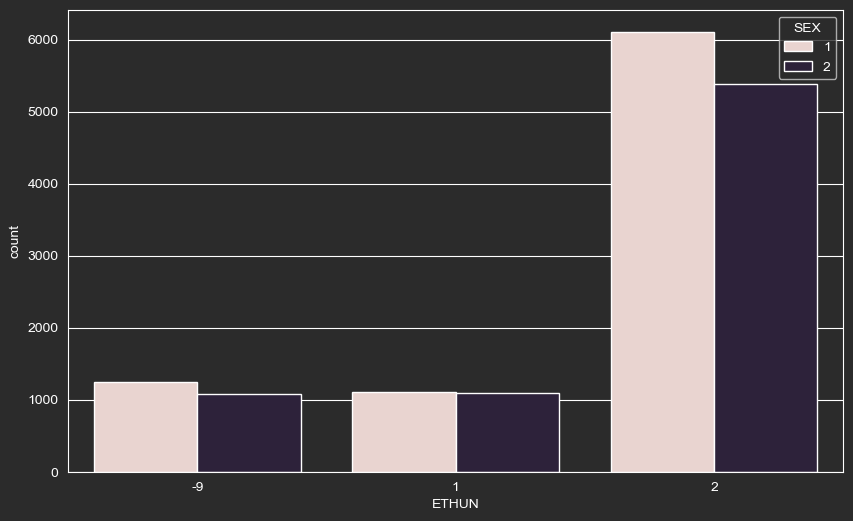

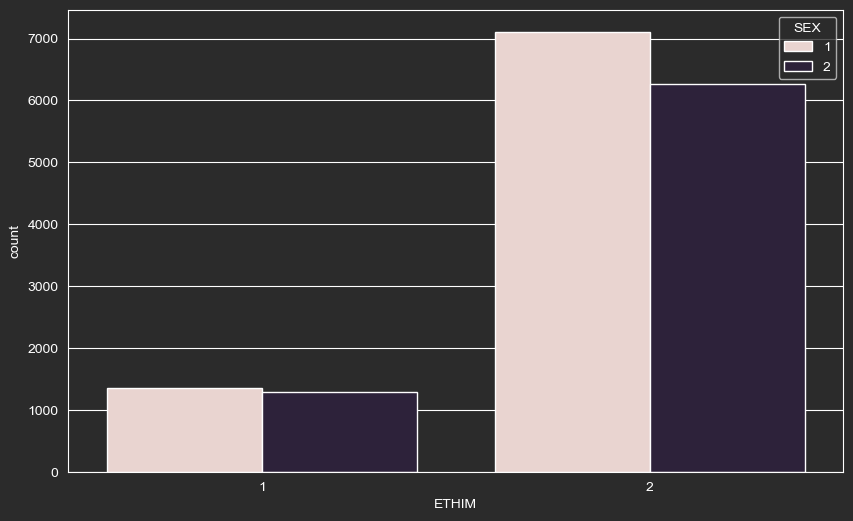

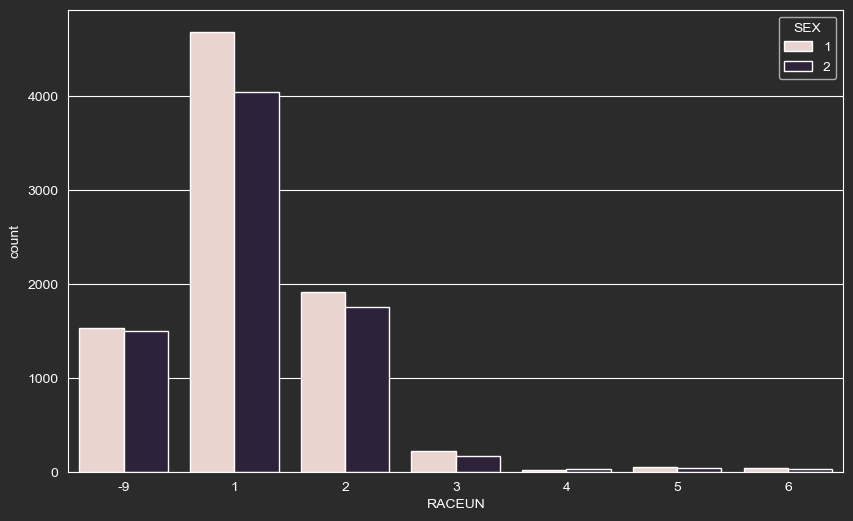

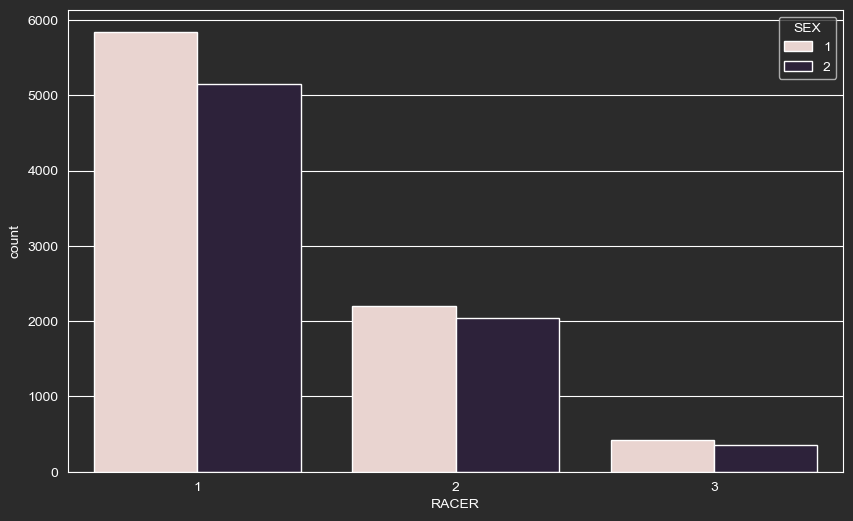

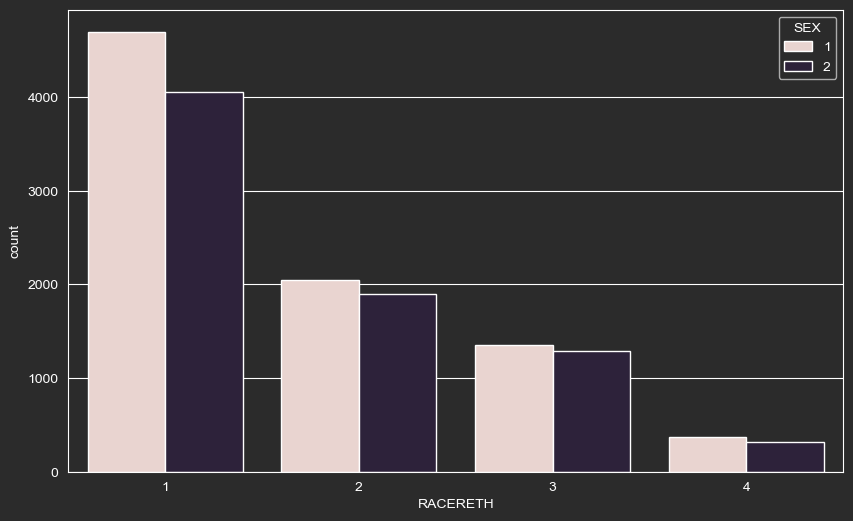

In [28]:
for col in ["ETHUN","ETHIM","RACEUN","RACER","RACERETH"]:
    sns.countplot(data=df,x=col,hue="SEX")
    plt.show()

## What are the most common reasons for emergency department visits?


### RFV1
Primary reason for visit

This is the most important variable because it captures the main reason the patient came to the ED.
### RFV2

### RFV3

<Axes: xlabel='RFV1', ylabel='count'>

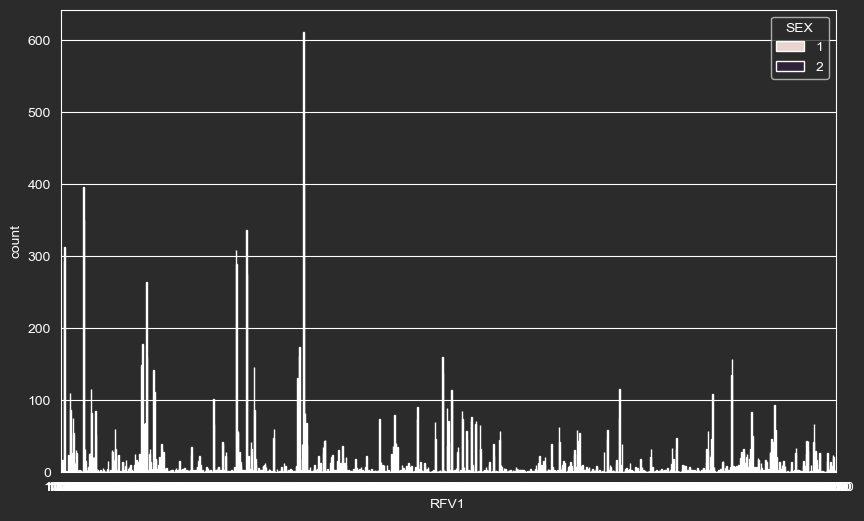

In [29]:
sns.countplot(data=df,x="RFV1",hue="SEX")

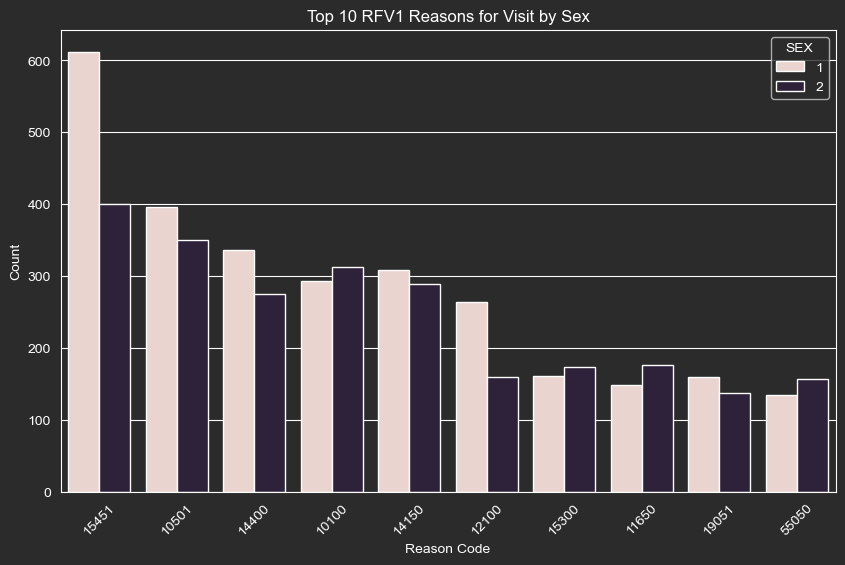

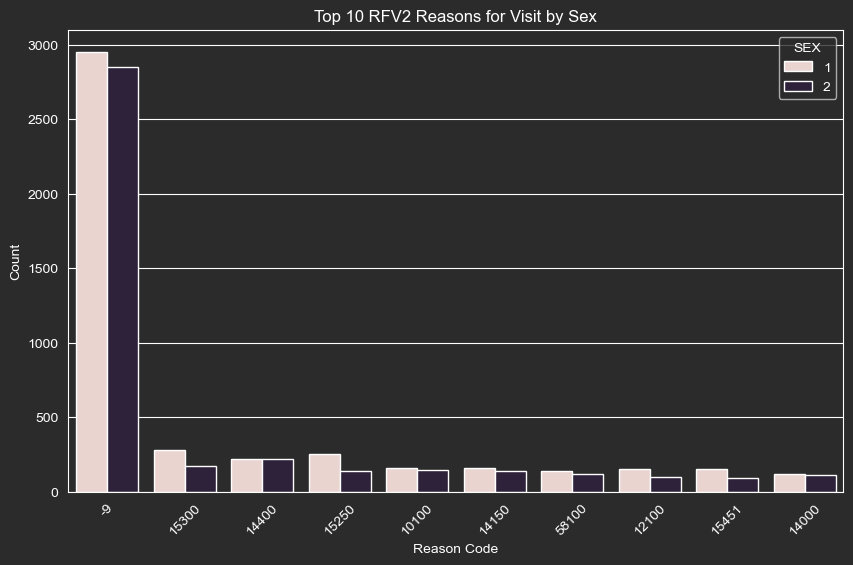

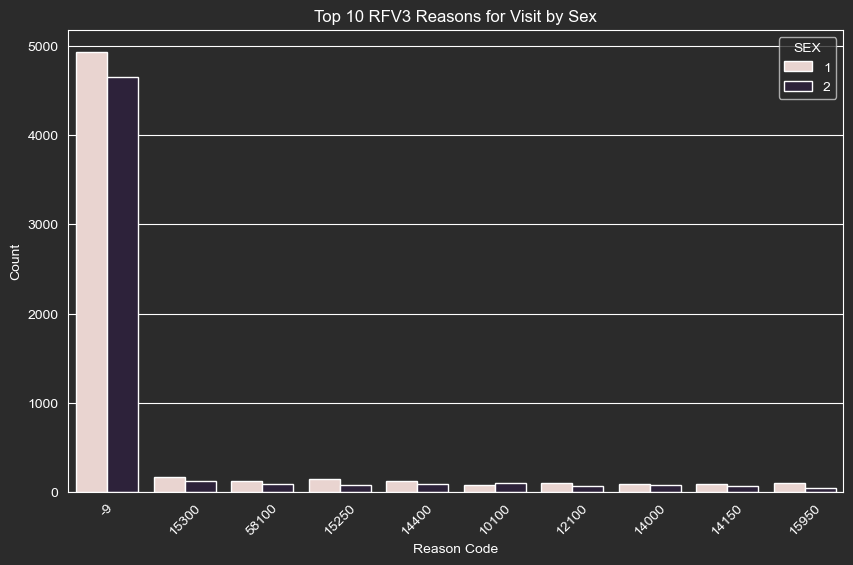

In [30]:
for col in ["RFV1", "RFV2", "RFV3"]:
    counts = df.groupby([col, "SEX"])[col].value_counts()
    counts = counts.reset_index(name="count")
    top10 = counts.groupby(col)["count"].sum().sort_values(ascending=False).index[:10]
    counts = counts[counts[col].isin(top10)]
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=counts,
        x=col,
        y="count",
        hue="SEX",
        order=top10
    )
    plt.title(f"Top 10 {col} Reasons for Visit by Sex")
    plt.xticks(rotation=45)
    plt.xlabel("Reason Code")
    plt.ylabel("Count")
    plt.show()

## What proportion of visits are due to injuries vs illnesses?

### INJURY

| Code   | Meaning                                                                  |
| ------ | ------------------------------------------------------------------------ |
| **0**  | Visit **not related to injury or poisoning** (illness/medical condition) |
| **1**  | Visit **related to injury or poisoning**                                 |
| **2**  | **Unknown whether injury-related**                                       |
| **-8** | Not ascertained                                                          |
| **-9** | Blank                                                                    |



In [31]:
df["INJURY"].value_counts()

INJURY
 0    10270
 1     4483
-8      813
 2      277
-9      182
Name: count, dtype: int64

<Axes: xlabel='INJURY', ylabel='count'>

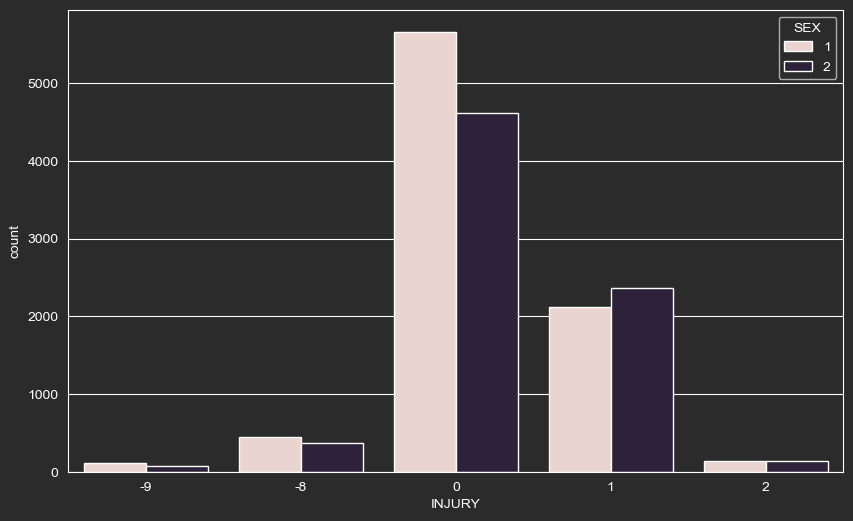

In [32]:
sns.countplot(data=df,x="INJURY",hue="SEX")

## Which diagnoses are most commonly recorded in ED visits?

| Code               | Diagnosis Description                                           |
| ------------------ | --------------------------------------------------------------- |
| **U071**           | COVID-19, virus identified                                      |
| **R079**           | Chest pain, unspecified                                         |
| **R109**           | Abdominal pain, unspecified                                     |
| **J069**           | Acute upper respiratory infection, unspecified                  |
| **M255**           | Pain in joint                                                   |
| **Z532**           | Procedure not carried out because patient left before treatment |
| **-9**             | Missing / blank diagnosis in dataset                            |
| **B349**           | Viral infection, unspecified                                    |
| **R519**           | Headache                                                        |
| **M796**           | Pain in limb                                                    |
| **I10** / **I10-** | Essential (primary) hypertension                                |
| **Z208**           | Contact with and suspected exposure to communicable diseases    |
| **R059**           | Cough                                                           |
| **R112**           | Nausea with vomiting, unspecified                               |
| **N390**           | Urinary tract infection, site not specified                     |
| **E119**           | Type 2 diabetes mellitus without complications                  |
| **R509**           | Fever, unspecified                                              |
| **R060**           | Shortness of breath                                             |
| **E860**           | Dehydration                                                     |



In [33]:
for col in ["DIAG1", "DIAG2", "DIAG3"]:
    print(df[col].value_counts()[:10])

DIAG1
U071    508
R079    406
R109    367
J069    332
M255    279
Z532    264
-9      227
B349    215
R519    204
M796    199
Name: count, dtype: int64
DIAG2
-9      7635
I10-     199
Z208     171
R059     163
U071     150
R109     142
R112     124
M255     118
J069     114
N390     113
Name: count, dtype: int64
DIAG3
-9      11774
I10-      158
Z208      121
N390       57
R059       56
E119       53
R109       52
R509       48
R060       47
E860       46
Name: count, dtype: int64


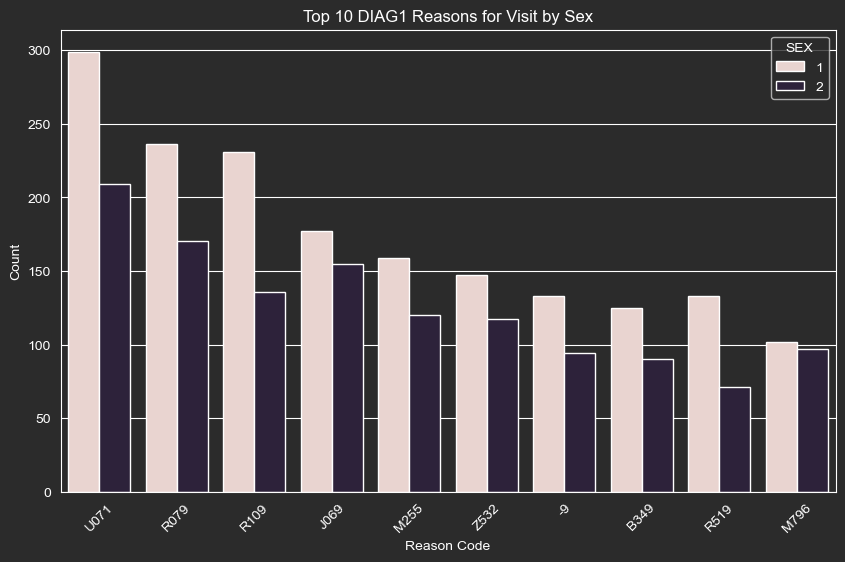

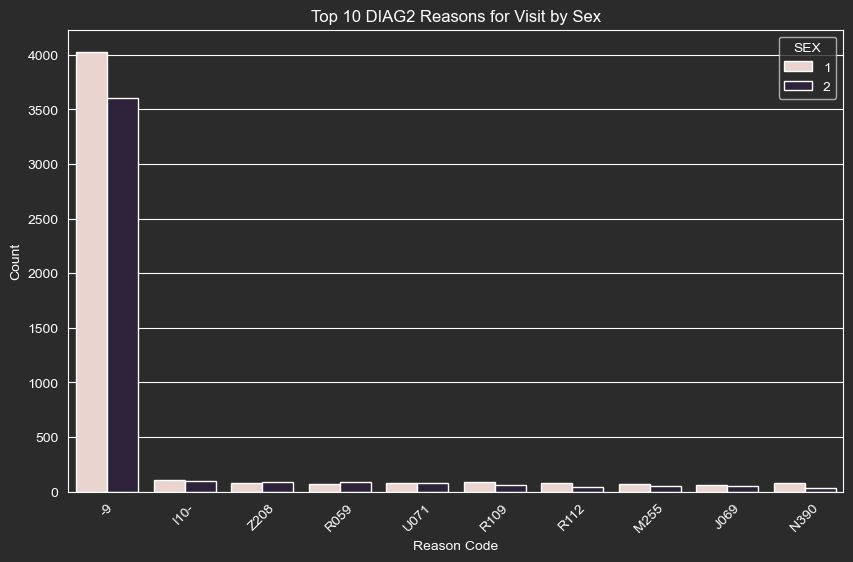

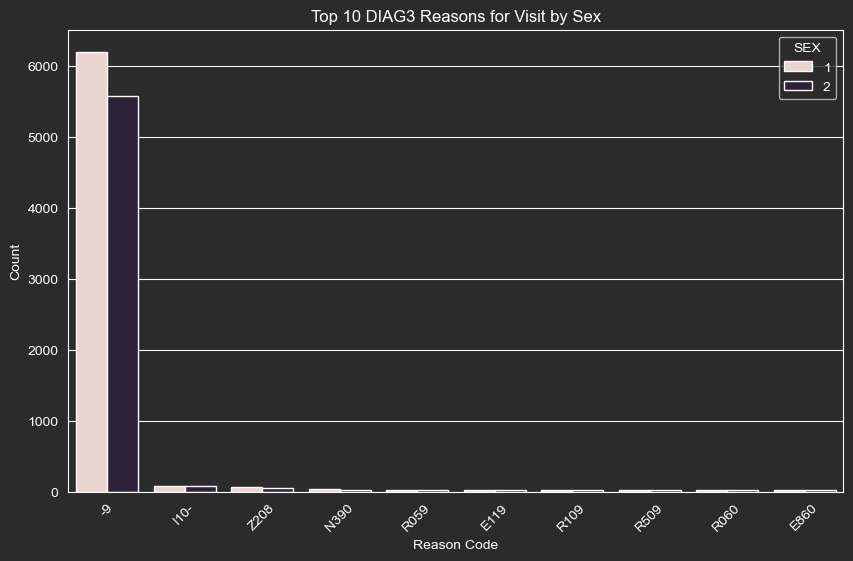

In [34]:
for col in ["DIAG1", "DIAG2", "DIAG3"]:
    counts = df.groupby([col, "SEX"])[col].value_counts()
    counts = counts.reset_index(name="count")
    top10 = counts.groupby(col)["count"].sum().sort_values(ascending=False).index[:10]
    counts = counts[counts[col].isin(top10)]
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=counts,
        x=col,
        y="count",
        hue="SEX",
        order=top10
    )
    plt.title(f"Top 10 {col} Reasons for Visit by Sex")
    plt.xticks(rotation=45)
    plt.xlabel("Reason Code")
    plt.ylabel("Count")
    plt.show()

## What is the distribution of triage acuity levels among ED visits?

In [35]:
df["IMMEDR"].describe()

count    16025.000000
mean         0.384462
std          5.179554
min         -9.000000
25%         -8.000000
50%          3.000000
75%          4.000000
max          7.000000
Name: IMMEDR, dtype: float64

<Axes: xlabel='IMMEDR', ylabel='count'>

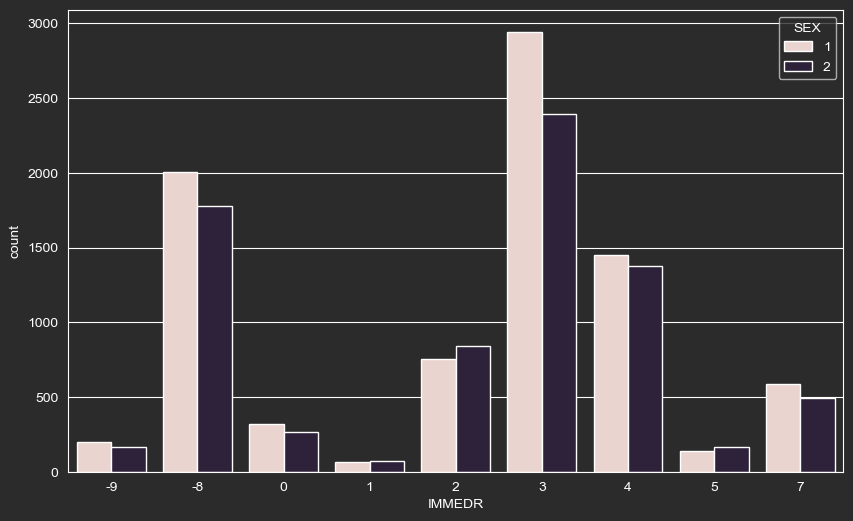

In [36]:
sns.countplot(data=df,x="IMMEDR",hue="SEX")

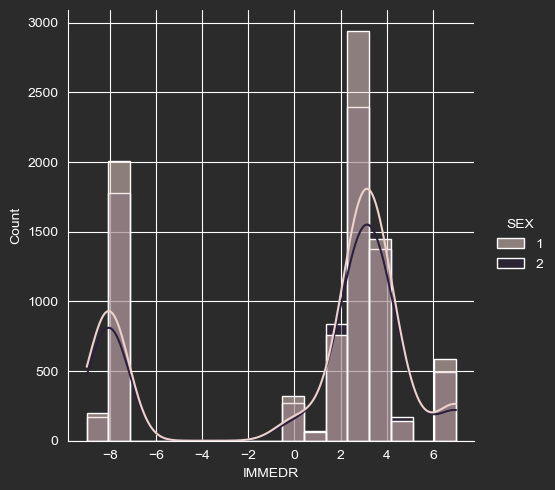

In [37]:
sns.displot(data=df,x="IMMEDR",hue="SEX",kde=True)

## Are older patients more likely to have higher triage acuity?

<Axes: xlabel='IMMEDR', ylabel='AGER'>

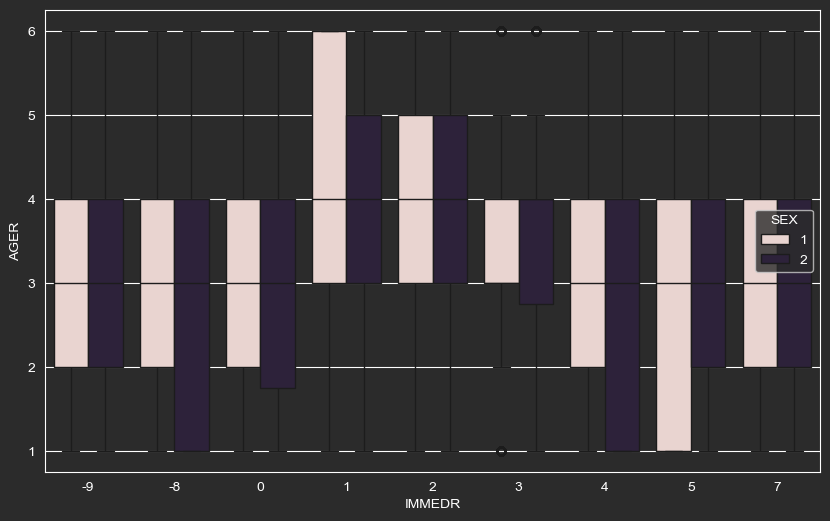

In [38]:
sns.boxplot(data=df,x="IMMEDR",y="AGER",hue="SEX")

In [39]:
df.groupby("IMMEDR")["AGER"].describe()

,count,mean,std,min,25%,50%,75%,max
IMMEDR,,,,,,,,
-9,364.0,3.016484,1.521110,1.0,2.0,3.0,4.0,6.0
-8,3788.0,3.167635,1.584063,1.0,2.0,3.0,4.0,6.0
0,587.0,3.103918,1.520430,1.0,2.0,3.0,4.0,6.0
1,139.0,3.992806,1.515602,1.0,3.0,4.0,5.0,6.0
2,1595.0,3.773041,1.456143,1.0,3.0,4.0,5.0,6.0
3,5340.0,3.469850,1.482251,1.0,3.0,3.0,4.0,6.0
4,2826.0,2.711253,1.394094,1.0,1.0,3.0,4.0,6.0
5,307.0,2.876221,1.507385,1.0,1.0,3.0,4.0,6.0
7,1079.0,3.249305,1.444694,1.0,2.0,3.0,4.0,6.0


<Axes: xlabel='IMMEDR', ylabel='AGE'>

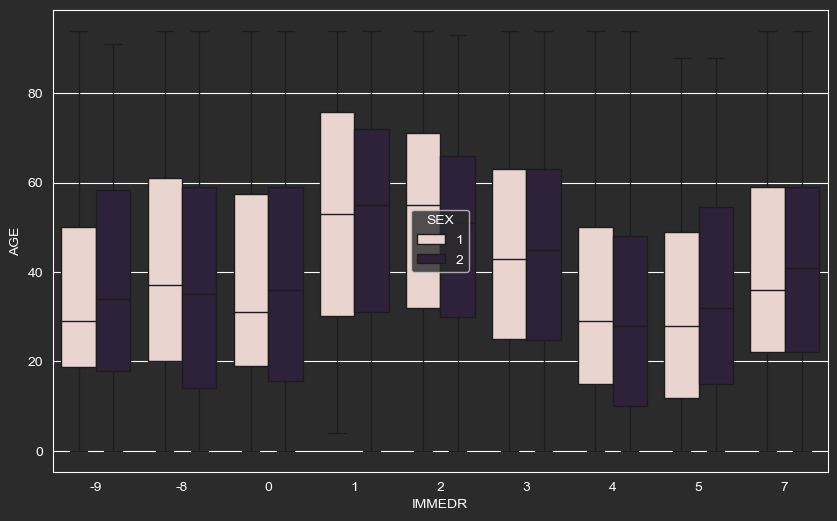

In [40]:
sns.boxplot(data=df,x="IMMEDR",y="AGE",hue="SEX")

In [41]:
df.groupby("IMMEDR")["AGE"].describe()

,count,mean,std,min,25%,50%,75%,max
IMMEDR,,,,,,,,
-9,364.0,35.879121,24.484699,0.0,18.0,32.0,54.0,94.0
-8,3788.0,38.935058,25.867786,0.0,18.0,36.0,60.0,94.0
0,587.0,37.596252,24.817192,0.0,18.0,34.0,58.0,94.0
1,139.0,52.129496,25.375394,0.0,31.0,53.0,74.0,94.0
2,1595.0,49.085893,23.924799,0.0,31.0,53.0,68.0,94.0
3,5340.0,43.902996,24.330980,0.0,25.0,43.0,63.0,94.0
4,2826.0,31.457537,22.741700,0.0,12.0,29.0,49.0,94.0
5,307.0,33.771987,24.233615,0.0,13.0,31.0,53.5,88.0
7,1079.0,40.228916,23.788931,0.0,22.0,39.0,59.0,94.0


## Which **chief complaints are associated with the highest acuity levels**?


In [42]:
df_clean = df[df["IMMEDR"].isin([1,2,3,4,5])]

In [43]:
df_clean

,VMONTH,VDAYR,ARRTIME,WAITTIME,LOV,AGE,AGER,AGEDAYS,RESIDNCE,SEX,...,RX30V3C2,RX30V3C3,RX30V3C4,SETTYPE,YEAR,CSTRATM,CPSUM,PATWT,EDWT,BOARDED
0,9,2,0604,10,228,23,2,-7,1,1,...,,,,3,2022,20122201,100001,3665.569580,8.36413,-7
2,9,2,1419,70,551,19,2,-7,1,2,...,,,,3,2022,20122201,100001,3665.569580,NaN,-7
4,9,2,2243,14,168,18,2,-7,1,1,...,,,,3,2022,20122201,100001,3665.569580,NaN,-7
7,9,3,1830,13,-9,46,4,-7,1,2,...,,,,3,2022,20122201,100001,3665.569580,NaN,-7
8,9,4,0532,109,113,46,4,-7,1,2,...,,,,3,2022,20122201,100001,3665.569580,NaN,-7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16018,12,4,2100,74,130,22,2,-7,1,2,...,,,,3,2022,40400000,36,18591.699219,NaN,-7
16019,12,4,0919,31,95,14,1,-7,1,1,...,,,,3,2022,40400000,36,18591.699219,NaN,-7
16020,12,5,0659,13,94,56,4,-7,1,1,...,,,,3,2022,40400000,36,10328.721680,NaN,-7
16022,11,2,0956,105,203,44,3,-7,1,1,...,,,,3,2022,40400000,36,10328.721680,NaN,-7


In [44]:
counts = df_clean.groupby(["IMMEDR", "RFV1"]).size()

In [45]:
counts

IMMEDR  RFV1 
1       10200    2
        10501    3
        10601    1
        10603    1
        10700    1
                ..
5       59300    2
        67000    1
        71000    1
        71400    5
        89980    2
Length: 1118, dtype: int64

In [46]:
top_rfv = counts.groupby(level=0).idxmax()

| RFV Code  | Complaint Meaning                                                                                                                                                                                         |
| --------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **10501** | **Chest pain** (typical cardiovascular or chest discomfort complaint) ([CDC][1])                                                                                                                          |
| **14150** | **Shortness of breath / Respiratory distress** (a common respiratory symptom) ([CDC][1])                                                                                                                  |
| **14400** | **Cough** (a respiratory symptom) ([Restored CDC][2])                                                                                                                                                     |
| **15451** | **Abdominal pain** (a common general symptom) ([CDC][1])                                                                                                                                                  |
| **45550** | **Follow‑up/Other related conditions** (often administrative reasons or follow‑up for prior care) — RVC codes in the 45xxx range are administrative or other non‑symptom reasons for visit ([CDC FTP][3]) |

[1]: https://www.cdc.gov/nchs/data/hus/hus12.pdf?utm_source=chatgpt.com "Copyright information"
[2]: https://restoredcdc.org/www.cdc.gov/nchs/products/databriefs/db517.htm%3FCDC_AA_refVal%3Dhttps%3A/www.cdc.gov/nchs/updates/feature-3.html?utm_source=chatgpt.com "Restored CDC | Products - Data Briefs - Number 517 - December 2024"
[3]: https://ftp.cdc.gov/pub/health_statistics/nchs/dataset_documentation/NHAMCS/doc15_ed.pdf?utm_source=chatgpt.com "2015 NHAMCS MICRO-DATA FILE DOCUMENTATION"


## Do **ambulance arrivals have higher acuity than walk-in patients**?

| Code   | Meaning                                      |
| ------ | -------------------------------------------- |
| **1**  | Arrived by **ambulance (EMS)**               |
| **2**  | **Walk-in** / arrived by other private means |
| **-8** | Not ascertained                              |
| **-9** | Blank / missing                              |


In [47]:
df["ARREMS"].value_counts()

ARREMS
 2    12682
 1     2848
-8      389
-9      106
Name: count, dtype: int64

<Axes: xlabel='ARREMS', ylabel='count'>

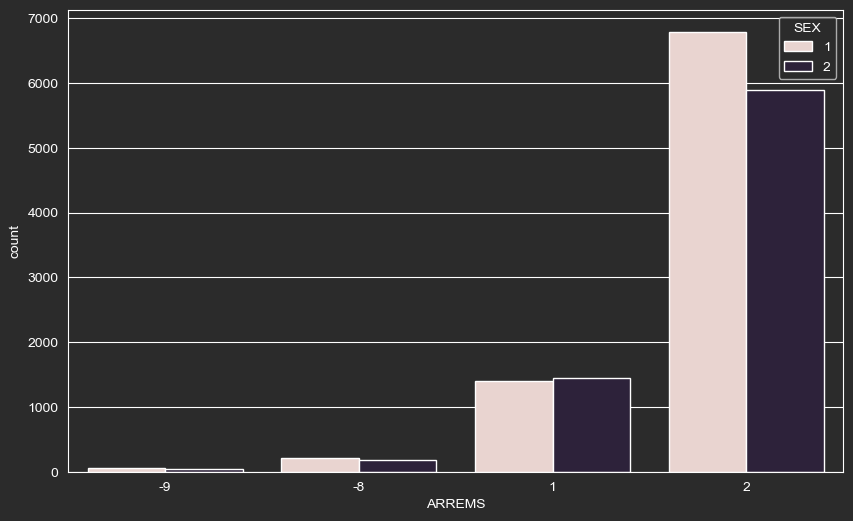

In [48]:
sns.countplot(data=df,x="ARREMS",hue="SEX")

<Axes: xlabel='ARREMS', ylabel='count'>

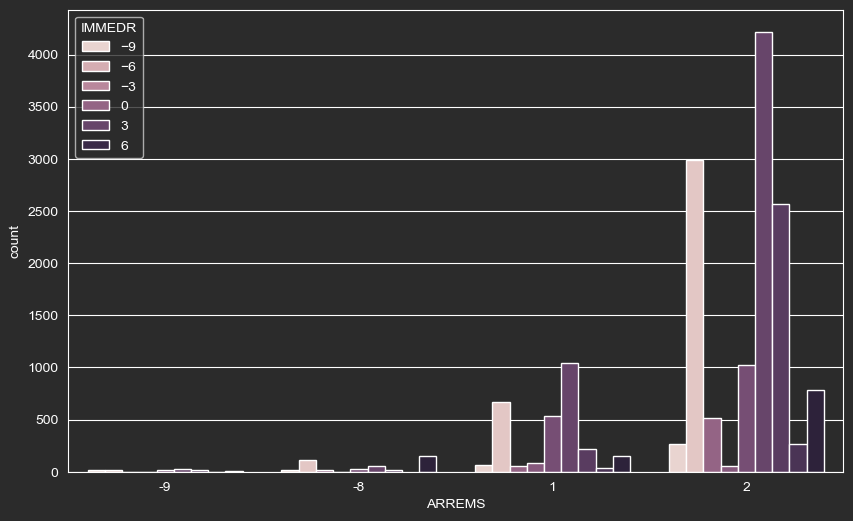

In [49]:
sns.countplot(data=df,x="ARREMS",hue="IMMEDR")

In [50]:
df_clean["HIGH_ACUITY"] = df_clean["IMMEDR"].isin([1,2,3]).astype(int)

df_clean.groupby("ARREMS")["HIGH_ACUITY"].count()

ARREMS
-9      67
-8      98
 1    1914
 2    8128
Name: HIGH_ACUITY, dtype: int64

## What percentage of patients **arrive by ambulance**?

In [51]:
df_clean = df[df["ARREMS"].isin([1,2])]

In [52]:
df_clean["ARREMS"].value_counts(normalize=True) * 100

ARREMS
2    81.661301
1    18.338699
Name: proportion, dtype: float64

## Are **ambulance arrivals associated with higher admission rates**?
### ADMITHOS
| Code  | Meaning                                                        |
| ----- | -------------------------------------------------------------- |
| **1** | Patient **admitted to the hospital**                           |
| **0** | Patient **not admitted** (discharged, transferred, left, etc.) |



<Axes: xlabel='ARREMS', ylabel='count'>

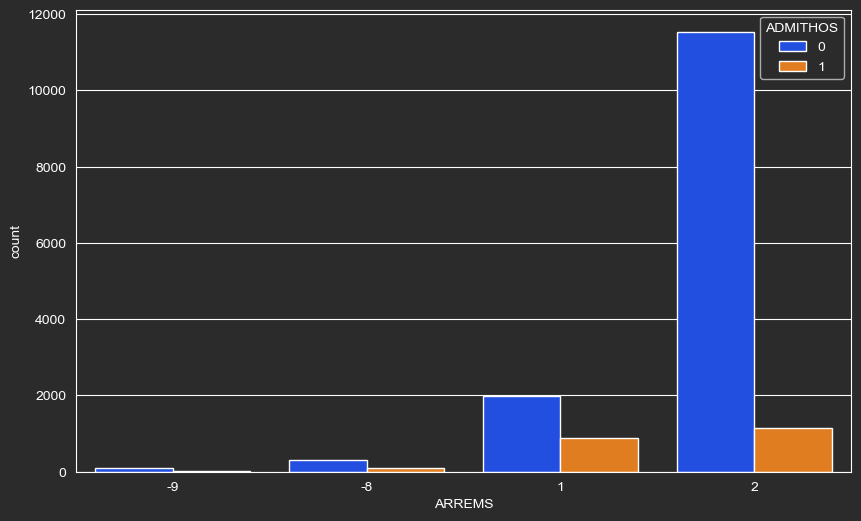

In [53]:
sns.countplot(data=df,x="ARREMS",hue="ADMITHOS")

In [54]:
df.groupby("ADMITHOS")["ARREMS"].value_counts()

ADMITHOS  ARREMS
0          2        11536
           1         1976
          -8          304
          -9           88
1          2         1146
           1          872
          -8           85
          -9           18
Name: count, dtype: int64

## Do **ambulance arrivals have shorter wait times before being seen**?

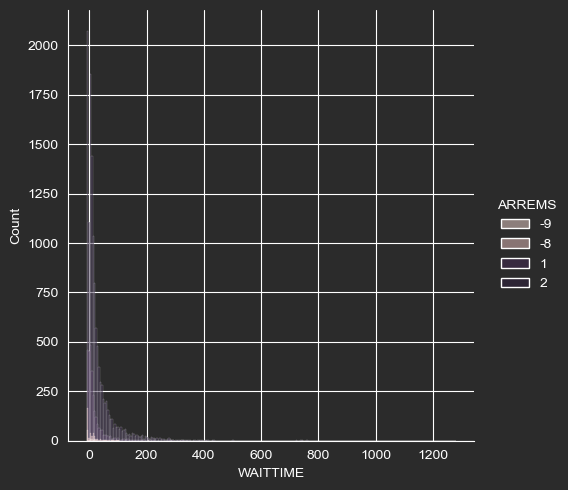

In [55]:
sns.displot(data=df,x="WAITTIME",hue="ARREMS")

<Axes: xlabel='ARREMS', ylabel='WAITTIME'>

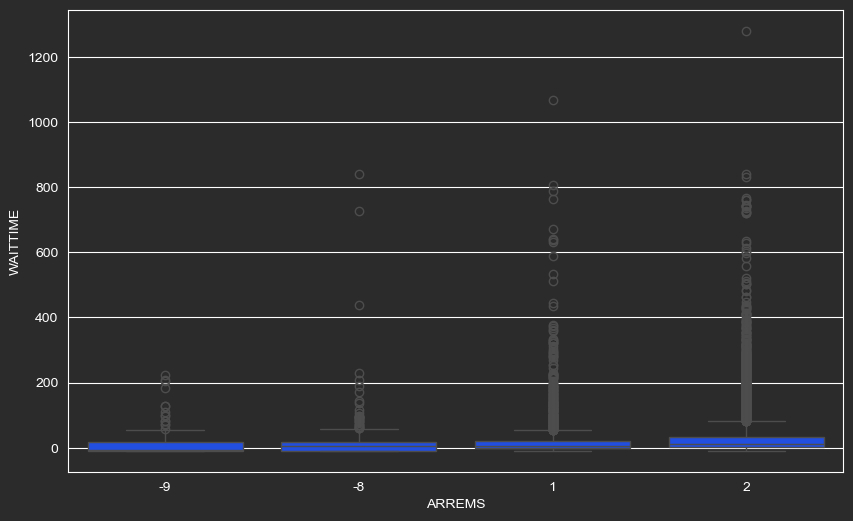

In [56]:
sns.boxplot(data=df,x="ARREMS",y="WAITTIME")

In [57]:
df.groupby("ARREMS")["WAITTIME"].describe()

,count,mean,std,min,25%,50%,75%,max
ARREMS,,,,,,,,
-9,106.0,17.547170,48.619834,-9.0,-9.0,-7.0,17.0,222.0
-8,389.0,17.485861,67.656523,-9.0,-9.0,4.0,18.0,839.0
1,2848.0,22.661517,62.090040,-9.0,0.0,7.0,22.0,1066.0
2,12682.0,30.068128,61.707970,-9.0,1.0,11.0,33.0,1280.0


## What are the **distributions of key vital signs** (heart rate, temperature, blood pressure)?

| Vital Sign               | Variable             |
| ------------------------ | -------------------- |
| Heart rate               | `PULSE`              |
| Temperature              | `TEMPF` (Fahrenheit) |
| Systolic blood pressure  | `BPSYS`              |
| Diastolic blood pressure | `BPDIAS`             |


In [58]:
df[["PULSE","TEMPF","BPSYS","BPDIAS","RESPR"]].describe()

,PULSE,TEMPF,BPSYS,BPDIAS,RESPR
count,16025.000000,16025.000000,16025.000000,16025.000000,16025.000000
mean,91.108019,924.661217,118.893978,69.527176,18.285429
std,75.043084,232.879252,50.031284,31.688955,9.052974
min,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,74.000000,976.000000,111.000000,65.000000,16.000000
50%,87.000000,981.000000,128.000000,76.000000,18.000000
75%,102.000000,986.000000,145.000000,87.000000,20.000000
max,998.000000,1056.000000,289.000000,998.000000,150.000000


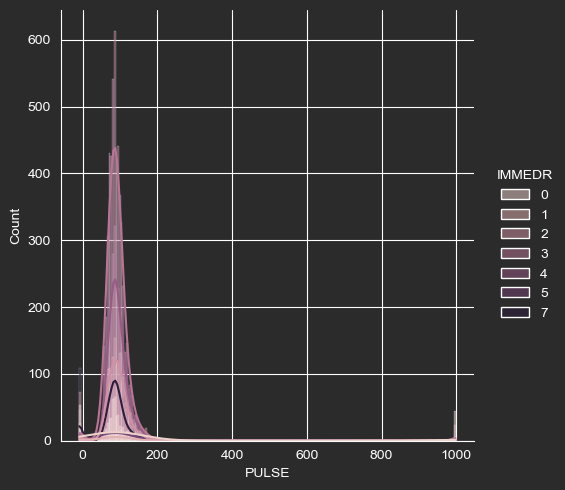

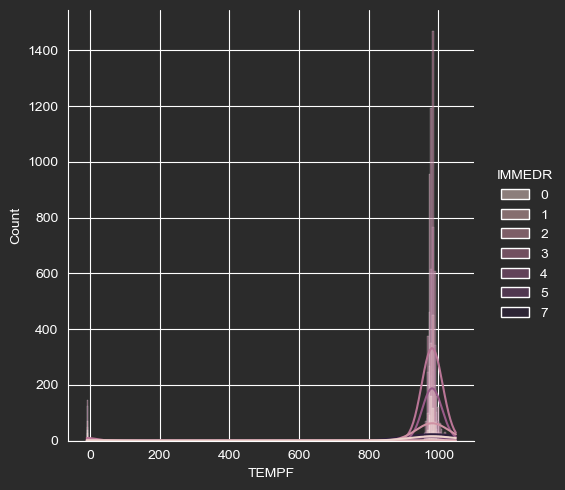

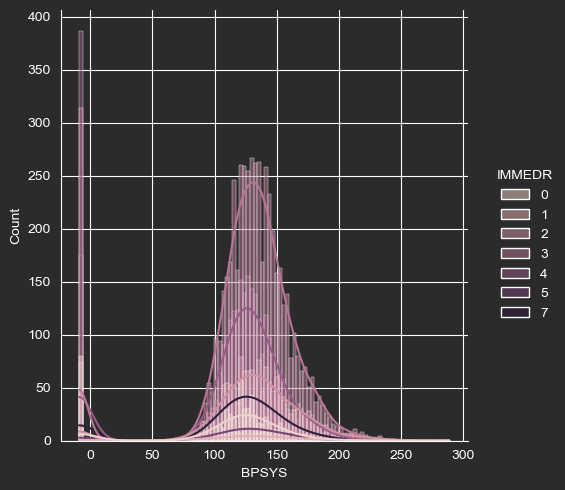

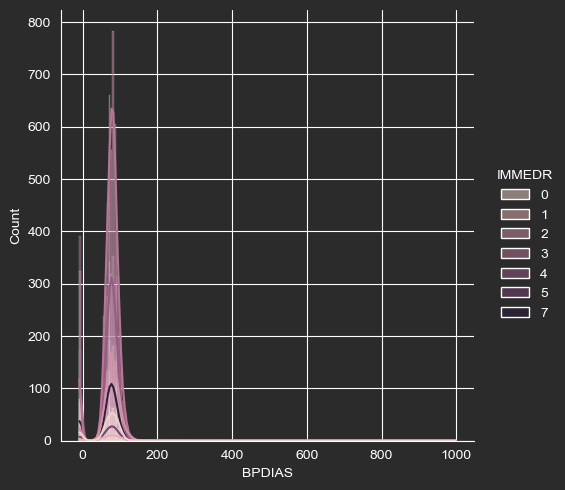

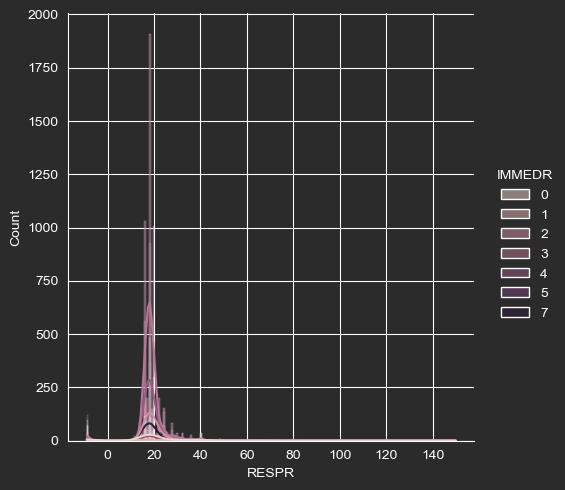

In [59]:
df_clean = df[df["IMMEDR"].isin(range(0, 8))]
for col in ["PULSE","TEMPF","BPSYS","BPDIAS","RESPR"]:

    sns.displot(data=df_clean,x=col,hue="IMMEDR",kde=True)
    plt.show()

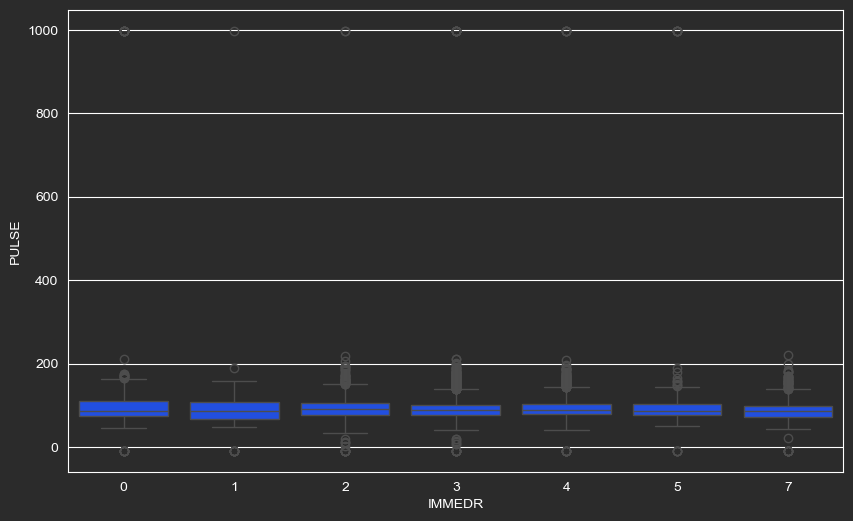

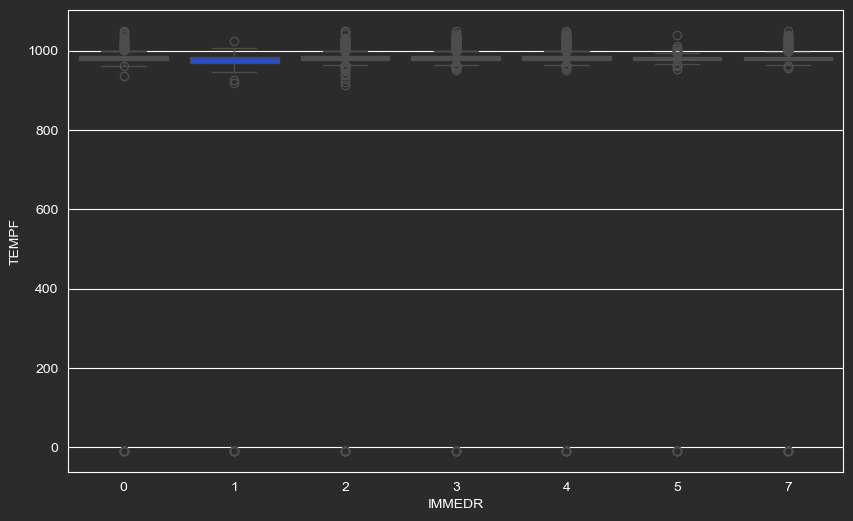

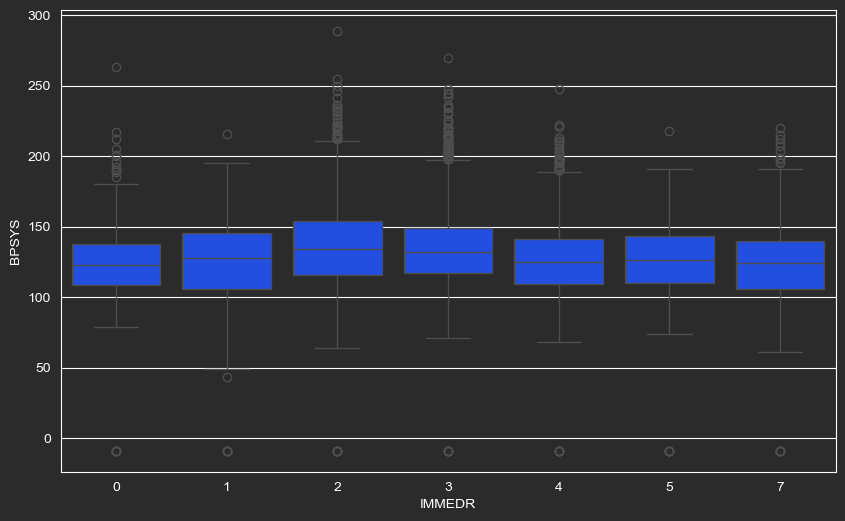

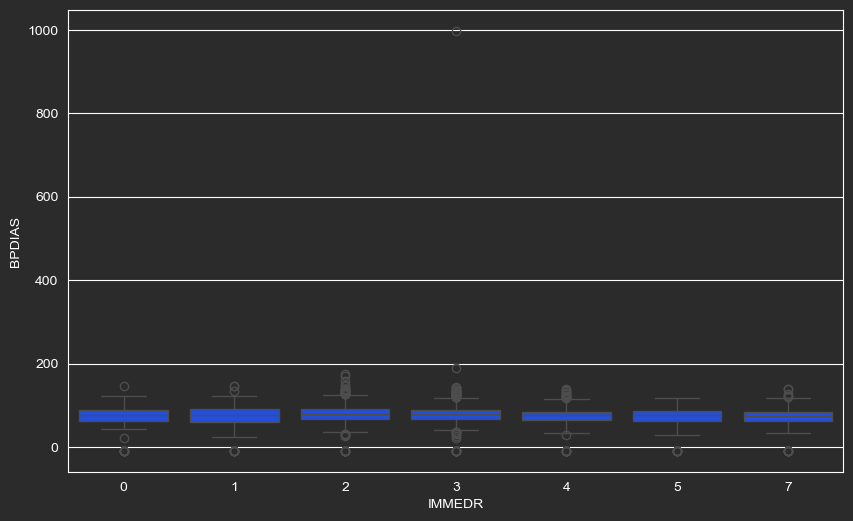

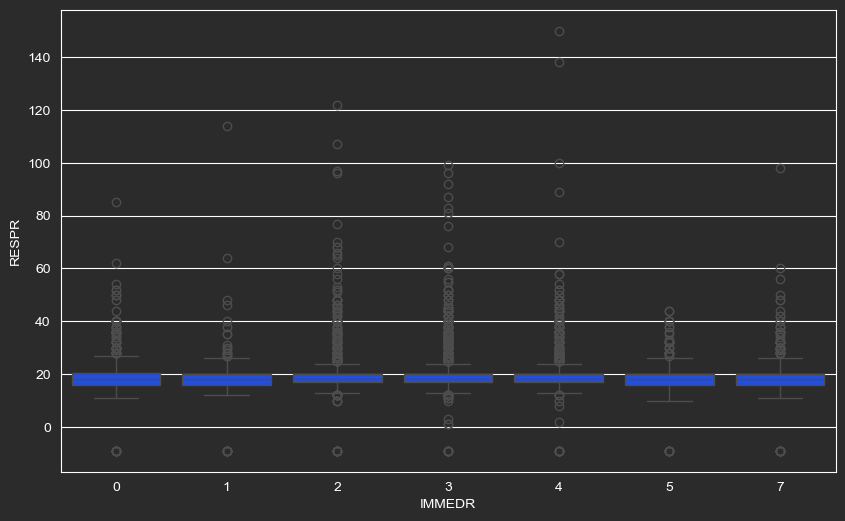

In [60]:
for col in ["PULSE","TEMPF","BPSYS","BPDIAS","RESPR"]:
    sns.boxplot(data=df_clean,x="IMMEDR",y=col)
    plt.show()